
== K sweep summary ==
 K      Inertia  Silhouette (↑)  Davies-Bouldin (↓)  Calinski-Harabasz (↑)
 2 2002313.0000          0.3669              1.1416             11952.6860
 3 1411837.3750          0.3574              1.0319             12672.9581
 4 1128984.1250          0.3641              0.9121             12336.7949
 5  845010.8750          0.3992              0.8192             14045.2792
 6  684541.5625          0.3993              0.7798             14889.6228
 7  605340.3750          0.3839              0.8552             14353.4147
 8  560973.5000          0.3522              0.9799             13530.1928
 9  496524.0625          0.3412              0.9935             13669.1173
10  451299.0625          0.3329              0.9687             13629.8732
[INFO] Saved K sweep summary: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\k_sweep_summary.csv

K vs silhouette:
  K=2: silhouette=0.3669
  K=3: silhouette=0.3574
  K=4: silhouette=0.3641
  K=5: silhouette=0

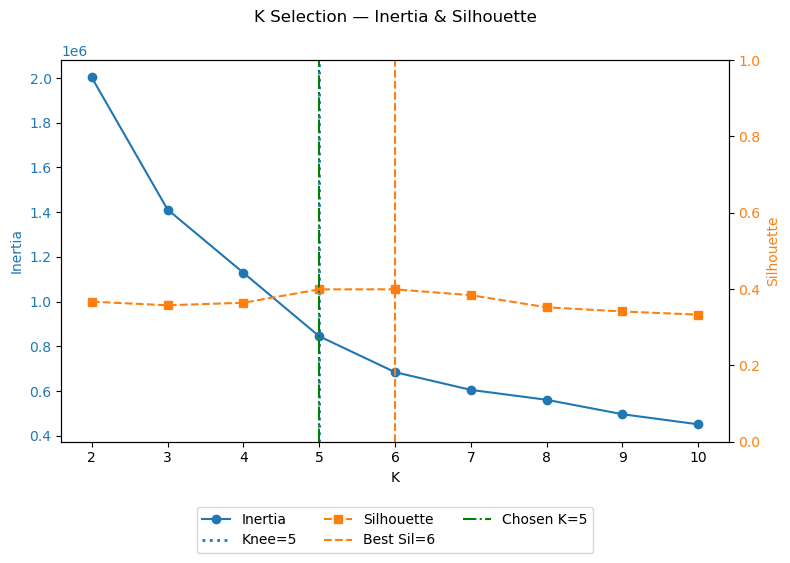

[INFO] Saved: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\k_selection.png

[Metrics @ K=5] Silhouette=0.407 | DBI=0.797 | CH=457892.9
Stability @ K=5 (ARI): mean=0.817 ± 0.147


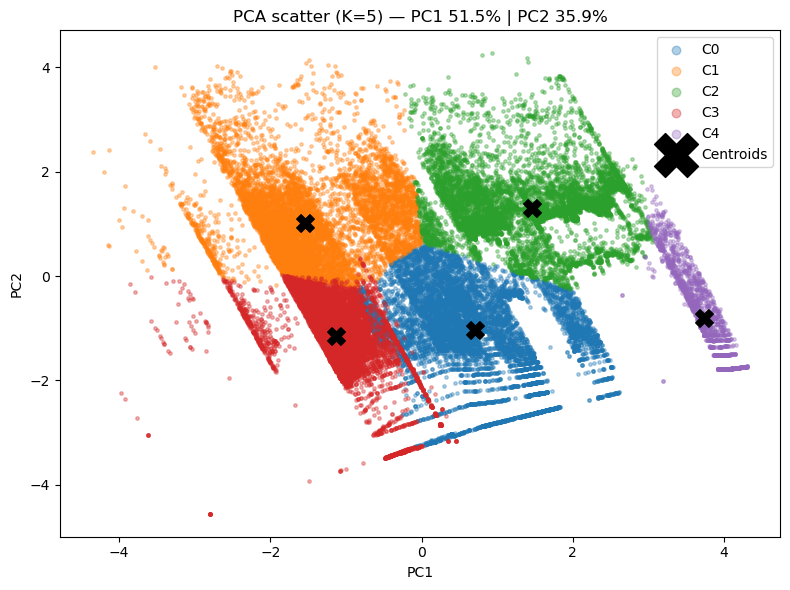

[INFO] Saved: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\pca_scatter.png


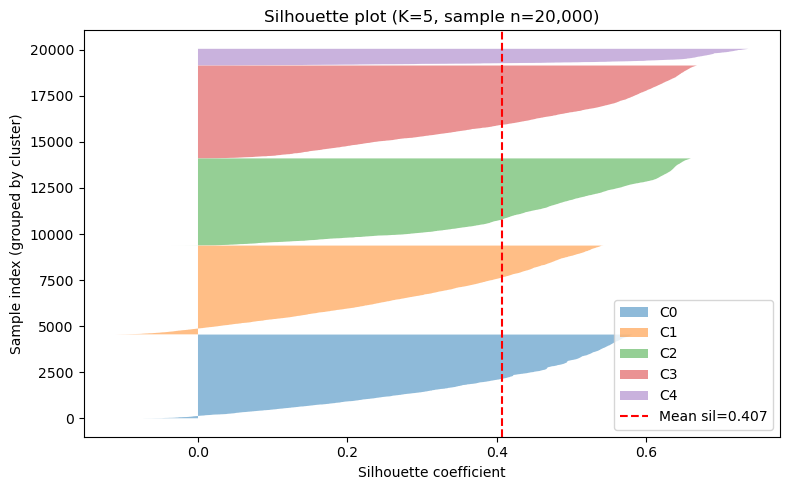

[INFO] Saved: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\silhouette_plot.png
[INFO] Exported clustered dataset to: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\Open_Data_Clustering_results.csv

== Cluster sizes ==
 cluster
0    143078
1    154759
2    151005
3    162538
4     27726
Name: count, dtype: int64

== Cluster profile (feature means) ==
          usage_total  age_days  since_update_days  usage_per_365  \
cluster                                                            
0              38.02    777.04             768.16          24.59   
1            2397.62    312.82             222.72        4079.38   
2            1121.61   1814.43            1799.13         242.14   
3              50.43    297.53             129.44          91.09   
4              35.70   3421.06            2677.15           3.78   

         staleness_ratio  
cluster                   
0                   0.97  
1                   0.64  
2                   0.99

In [1]:
%%time

# ================================
# Clustering with Elbow (Knee) + Silhouette + PCA Plots
# + DBI/CH metrics + Stability (ARI) + Rich Profiles
# ================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,     # [ADDED]
)
from sklearn.metrics import adjusted_rand_score          # [ADDED]

# Try to import KneeLocator; if unavailable, we run without elbow
try:
    from kneed import KneeLocator
    HAVE_KNEE = True
except Exception as _:
    HAVE_KNEE = False
    print("[WARN] 'kneed' not available; elbow detection will be skipped. Use best silhouette instead.")

# -------------------------------
# 0) Config (EDIT THESE)
# -------------------------------
csv_path = r"C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\Open_Data_Clustering.csv"  # <-- update to your CSV
out_dir  = os.path.dirname(csv_path)

# K range and sampling knobs (adjust if you need more speed)
K_min, K_max      = 2, 10
sil_sample_size   = 20_000     # for silhouette/DBI/CH computations during sweep
pca_plot_samples  = 40_000     # how many points to render in the PCA scatter
random_state      = 42

# How to pick K when elbow != best silhouette: choose "knee" or "silhouette"
choose_k_policy   = "knee"     # <-- change to "silhouette" if you prefer

# Whether to also produce a silhouette plot for the chosen K (on a sample)
make_sil_plot     = True

# [ADDED] Extras
save_k_table_csv  = True       # salva a tabela-resumo do sweep de K
stability_runs    = 5          # quantas seeds para ARI (estabilidade)
remap_clusters_by = "usage_per_365"  # ou None para não remapear
export_profiles   = True       # exporta perfil rico dos clusters
make_corr_plot    = False      # plota heatmap de correlação (opcional)

# -------------------------------
# 1) Load CSV
# -------------------------------
df = pd.read_csv(csv_path)

# Required engineered columns from SQL (or compute them in Python beforehand)
required = ["usage_total","age_days","since_update_days","usage_per_365","staleness_ratio"]
missing  = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

# -------------------------------
# 2) Build the model matrix
# -------------------------------
X = df[required].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Optional but recommended: stabilize skew on usage features
for col in ["usage_total", "usage_per_365"]:
    X[col] = np.log1p(np.clip(X[col].values, 0, None))

# Standardize
scaler = StandardScaler()
Xs = scaler.fit_transform(X).astype(np.float32, copy=False)

# -------------------------------
# 3) K Sweep with MiniBatchKMeans
# -------------------------------
rng = np.random.default_rng(random_state)
n  = Xs.shape[0]
sil_idx = rng.choice(n, size=min(sil_sample_size, n), replace=False)
Xs_sil  = Xs[sil_idx]

Ks        = list(range(K_min, K_max+1))
inertias  = []
silscores = []
dbiscores = []   # [ADDED]
chiscores = []   # [ADDED]

for k in Ks:
    mbk = MiniBatchKMeans(
        n_clusters=k,
        n_init='auto',         # small during sweep
        batch_size=2048,
        max_iter=100,
        random_state=random_state
    )
    labels_mb = mbk.fit_predict(Xs)
    inertias.append(mbk.inertia_)

    # calcular métricas em amostra (coerência com silhouette amostrado)
    lbl_s = labels_mb[sil_idx]
    X_s  = Xs_sil
    if len(np.unique(lbl_s)) > 1:
        silscores.append(silhouette_score(X_s, lbl_s))
        dbiscores.append(davies_bouldin_score(X_s, lbl_s))       # [ADDED]
        chiscores.append(calinski_harabasz_score(X_s, lbl_s))     # [ADDED]
    else:
        silscores.append(np.nan); dbiscores.append(np.nan); chiscores.append(np.nan)

# Elbow (knee) via kneed if available
if HAVE_KNEE:
    kneedle = KneeLocator(Ks, inertias, curve='convex', direction='decreasing')
    k_knee  = int(kneedle.knee) if kneedle.knee is not None else None
else:
    k_knee  = None

# Best K by silhouette on the sample
k_sil_best = Ks[int(np.nanargmax(silscores))]

# Choose K by policy
if choose_k_policy.lower() == "knee" and (k_knee is not None):
    best_k = k_knee
else:
    best_k = k_sil_best

# Resumo tabular da varredura [ADDED]
k_table = pd.DataFrame({
    "K": Ks,
    "Inertia": inertias,
    "Silhouette (↑)": silscores,
    "Davies-Bouldin (↓)": dbiscores,
    "Calinski-Harabasz (↑)": chiscores
})

print("\n== K sweep summary ==")
print(k_table.round(4).to_string(index=False))

if save_k_table_csv:
    k_table_csv = os.path.join(out_dir, "k_sweep_summary.csv")
    k_table.to_csv(k_table_csv, index=False, encoding="utf-8")
    print(f"[INFO] Saved K sweep summary: {k_table_csv}")

print("\nK vs silhouette:")
for k, s in zip(Ks, silscores):
    print(f"  K={k}: silhouette={s:.4f}")
print(f"\nElbow (knee) on inertia: {k_knee}")
print(f"Best silhouette:         {k_sil_best}")
print(f"Chosen K:                {best_k}")

# -------------------------------
# 4) Plot + SAVE K-selection figure (elbow + silhouette)
# -------------------------------
fig, ax1 = plt.subplots(figsize=(8,5))
color1 = "tab:blue"
ax1.plot(Ks, inertias, "o-", color=color1, label="Inertia")
ax1.set_xlabel("K"); ax1.set_ylabel("Inertia", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:orange"
ax2.plot(Ks, silscores, "s--", color=color2, label="Silhouette")
ax2.set_ylabel("Silhouette", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 1)

if k_knee is not None:
    ax1.axvline(k_knee, color=color1, ls=":",  lw=2,   label=f"Knee={k_knee}")
ax2.axvline(k_sil_best,  color=color2, ls="--", lw=1.5, label=f"Best Sil={k_sil_best}")
ax2.axvline(best_k,      color="green", ls="-.", lw=1.5, label=f"Chosen K={best_k}")

fig.suptitle("K Selection — Inertia & Silhouette")
fig.legend(loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
k_png = os.path.join(out_dir, "k_selection.png")
plt.savefig(k_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"[INFO] Saved: {k_png}")

# -------------------------------
# 5) Fit final KMeans accurately
# -------------------------------
kmeans = KMeans(n_clusters=best_k, n_init='auto', algorithm='elkan', random_state=random_state)
labels = kmeans.fit_predict(Xs)
df["cluster"] = labels

# [ADDED] Métricas no dataset completo para o K escolhido
if len(np.unique(labels)) > 1:
    sil_full = silhouette_score(Xs, labels)
    dbi_full = davies_bouldin_score(Xs, labels)
    chi_full = calinski_harabasz_score(Xs, labels)
    print(f"\n[Metrics @ K={best_k}] Silhouette={sil_full:.3f} | DBI={dbi_full:.3f} | CH={chi_full:.1f}")
else:
    print("\n[Metrics] Only one cluster found; metrics not applicable.")

# -------------------------------
# 5.1) [ADDED] Estabilidade (ARI) para o K escolhido
# -------------------------------
def kmeans_stability(X, k, runs=5, seed=42):
    lbls = []
    for r in range(runs):
        km = KMeans(n_clusters=k, n_init='auto', algorithm='elkan', random_state=seed+r)
        lbls.append(km.fit_predict(X))
    pairs = [(i, j) for i in range(runs) for j in range(i+1, runs)]
    aris = [adjusted_rand_score(lbls[i], lbls[j]) for i, j in pairs]
    return float(np.mean(aris)), float(np.std(aris))

if stability_runs and stability_runs >= 2:
    ari_mean, ari_std = kmeans_stability(Xs, best_k, runs=stability_runs, seed=random_state)
    print(f"Stability @ K={best_k} (ARI): mean={ari_mean:.3f} ± {ari_std:.3f}")

# -------------------------------
# 6) PCA for visualization (2D)
# -------------------------------
pca = PCA(n_components=2, random_state=random_state)
XY = pca.fit_transform(Xs)
df["pca_x"] = XY[:,0]
df["pca_y"] = XY[:,1]
evr = pca.explained_variance_ratio_

# PCA scatter (sampled) with centroids
plot_idx   = rng.choice(n, size=min(pca_plot_samples, n), replace=False)
XYp, lblp  = XY[plot_idx], labels[plot_idx]
centers_2d = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))
for c in np.unique(lblp):
    m = (lblp == c)
    plt.scatter(XYp[m,0], XYp[m,1], s=6, alpha=0.35, label=f"C{c}")
plt.scatter(centers_2d[:,0], centers_2d[:,1], c="black", s=160, marker="X", label="Centroids")
plt.title(f"PCA scatter (K={best_k}) — PC1 {evr[0]*100:.1f}% | PC2 {evr[1]*100:.1f}%")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(frameon=True, markerscale=2.5)
plt.tight_layout()
pca_png = os.path.join(out_dir, "pca_scatter.png")
plt.savefig(pca_png, dpi=150)
plt.show()
print(f"[INFO] Saved: {pca_png}")

# -------------------------------
# 7) Optional: silhouette plot at chosen K (on sample)
# -------------------------------
if make_sil_plot:
    Xs_sp    = Xs[sil_idx]
    lbl_sp   = labels[sil_idx]
    if len(np.unique(lbl_sp)) > 1:
        sil_vals = silhouette_samples(Xs_sp, lbl_sp)

        y_lower = 10
        plt.figure(figsize=(8,5))
        for c in sorted(np.unique(lbl_sp)):
            c_sil  = np.sort(sil_vals[lbl_sp == c])
            size_c = c_sil.shape[0]
            y_upper = y_lower + size_c
            plt.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil, alpha=0.5, label=f"C{c}")
            y_lower = y_upper + 10

        mean_sil = float(np.mean(sil_vals))
        plt.axvline(mean_sil, color="red", ls="--", label=f"Mean sil={mean_sil:.3f}")
        plt.xlabel("Silhouette coefficient"); plt.ylabel("Sample index (grouped by cluster)")
        plt.title(f"Silhouette plot (K={best_k}, sample n={len(sil_vals):,})")
        plt.legend(frameon=True)
        plt.tight_layout()
        sil_png = os.path.join(out_dir, "silhouette_plot.png")
        plt.savefig(sil_png, dpi=150)
        plt.show()
        print(f"[INFO] Saved: {sil_png}")
    else:
        print("[INFO] Silhouette plot skipped (only one cluster on sample).")

# -------------------------------
# 8) Export enriched CSV for Power BI
# -------------------------------
#out_csv = os.path.splitext(csv_path)[0] + "_results.csv"
#df.to_csv(out_csv, index=False, encoding="utf-8")
#print(f"[INFO] Exported clustered dataset to: {out_csv}")

# -------------------------------
# 9) Quick console profile
# -------------------------------
sizes   = df["cluster"].value_counts().sort_index()
profile_mean = df.groupby("cluster")[required].mean().round(2)
print("\n== Cluster sizes ==\n", sizes)
print("\n== Cluster profile (feature means) ==\n", profile_mean)

# [ADDED] Perfil mais rico (mean/median/std + q25/q75) + export
def cluster_profile(df_src, by="cluster", cols=None):
    if cols is None:
        cols = required
    g = df_src.groupby(by)[cols]
    summary = g.agg(['mean','median','std']).round(2)
    q = g.quantile([0.25, 0.75]).unstack().rename(columns={0.25:'q25', 0.75:'q75'}).round(2)
    prof = pd.concat([summary, q], axis=1)
    return prof

profile_rich = cluster_profile(df, by="cluster", cols=required)
print("\n== Cluster profile (mean/median/std + q25/q75) ==\n", profile_rich)

if export_profiles:
    prof_csv = os.path.join(out_dir, "cluster_profile_rich.csv")
    profile_rich.to_csv(prof_csv, encoding="utf-8")
    print(f"[INFO] Saved cluster profile: {prof_csv}")

# [ADDED] Opcional: remapear clusters por ordem de 'usage_per_365' (mais estável p/ BI)
if remap_clusters_by and remap_clusters_by in required:
    order = df.groupby('cluster')[remap_clusters_by].mean().sort_values().index
    map_id = {old: new for new, old in enumerate(order)}
    df['cluster_ord'] = df['cluster'].map(map_id)

    #out_csv_ord = os.path.splitext(csv_path)[0] + "_results_ord.csv"
    #df.to_csv(out_csv_ord, index=False, encoding="utf-8")
    #print(f"[INFO] Exported (with cluster_ord) to: {out_csv_ord}")

# [ADDED] Opcional: correlação (desligado por padrão)
if make_corr_plot:
    try:
        import seaborn as sns
        corr = df[required].corr()
        plt.figure(figsize=(6,4))
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
        plt.title("Correlação (features originais)")
        plt.tight_layout()
        corr_png = os.path.join(out_dir, "features_correlation.png")
        plt.savefig(corr_png, dpi=150)
        plt.show()
        print(f"[INFO] Saved: {corr_png}")
    except Exception as e:
        print(f"[WARN] Corr plot skipped: {e}")





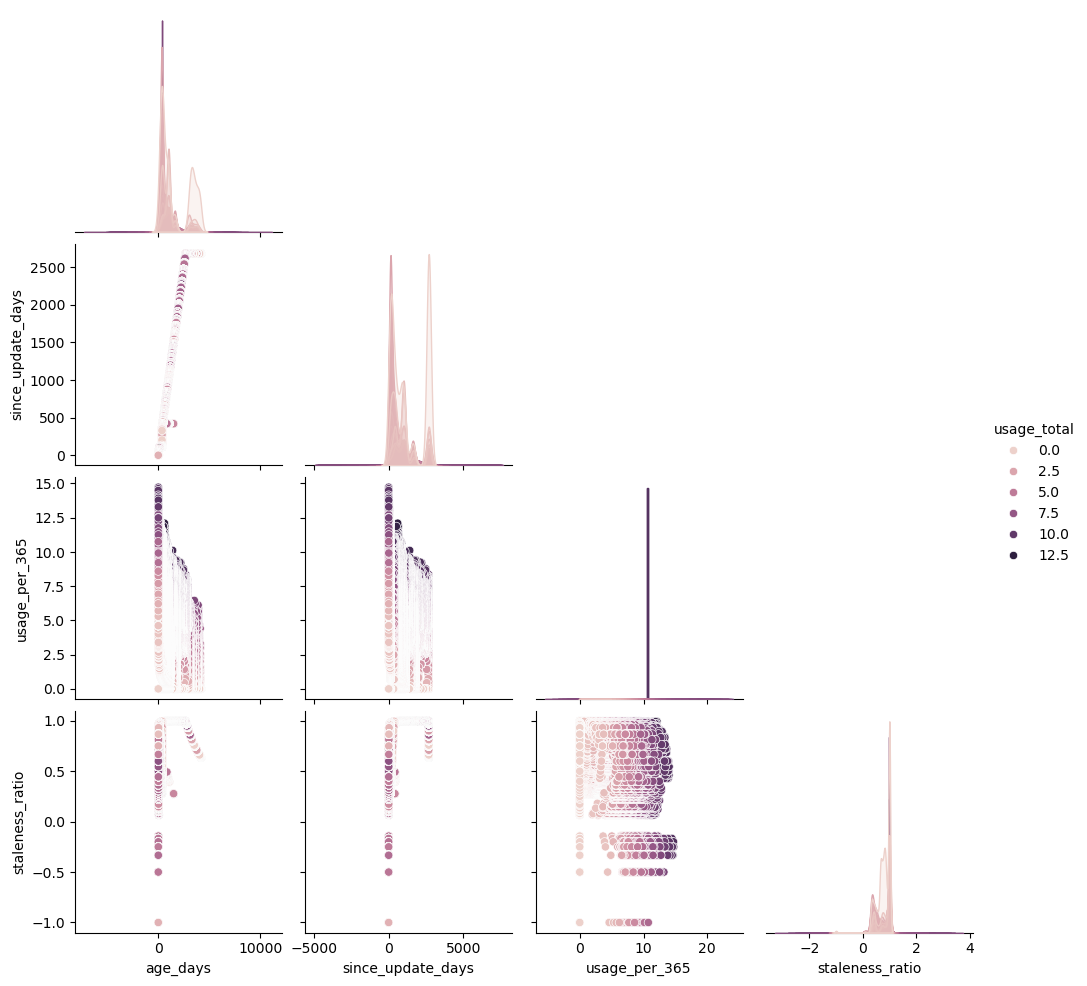

In [6]:
import seaborn as sns 
clustered = X[["usage_total","age_days","since_update_days","usage_per_365","staleness_ratio"]]
sns.pairplot(clustered,
            diag_kind = 'kde',
             hue='usage_total',
            corner = True,
            )
plt.show()

In [7]:
X.describe()

,usage_total,age_days,since_update_days,usage_per_365,staleness_ratio
count,639106.000000,639106.00000,639106.000000,639106.000000,639106.000000
mean,4.761568,902.49351,800.049696,4.409550,0.755323
std,2.116385,886.15187,837.832790,2.170346,0.276410
min,0.000000,0.00000,-1.000000,0.000000,-1.000000
25%,3.178054,272.00000,111.000000,2.986282,0.481481
50%,4.820282,447.00000,418.000000,4.483772,0.911290
75%,6.333280,1334.00000,1322.000000,5.800562,0.995483
max,12.608159,4218.00000,2679.000000,14.724055,0.999250
